# Part 3

### A.

In [325]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Preliminaries : setting the data

In [326]:
# Create dataframe with conversion rate
aud_to_usd = pd.read_csv('./data/DEXUSAL.csv') # aud to usd
eur_to_usd = pd.read_csv('./data/DEXUSEU.csv') # eur to usd
jpy_to_usd = pd.read_csv('./data/EXJPUS.csv') # usd to jpy
chf_to_usd = pd.read_csv('./data/DEXSZUS.csv') # usd to chf
gbp_to_usd = pd.read_csv('./data/DEXUSUK.csv') # gbp to usd

aud_to_usd = aud_to_usd.rename(columns={'DEXUSAL': 'exchange_rate'})
eur_to_usd = eur_to_usd.rename(columns={'DEXUSEU': 'exchange_rate'})
jpy_to_usd = jpy_to_usd.rename(columns={'EXJPUS': 'exchange_rate'})
chf_to_usd = chf_to_usd.rename(columns={'DEXSZUS': 'exchange_rate'})
gbp_to_usd = gbp_to_usd.rename(columns={'DEXUSUK': 'exchange_rate'})

In [327]:
# handle NaN values
aud_to_usd['exchange_rate'] = aud_to_usd['exchange_rate'].interpolate(method='linear') 
eur_to_usd['exchange_rate'] = eur_to_usd['exchange_rate'].interpolate(method='linear')
jpy_to_usd['exchange_rate'] = 1/jpy_to_usd['exchange_rate'].interpolate(method='linear')
chf_to_usd['exchange_rate'] = 1/chf_to_usd['exchange_rate'].interpolate(method='linear')
gbp_to_usd['exchange_rate'] = gbp_to_usd['exchange_rate'].interpolate(method='linear')

#transform these exchange rates into FX returns 
aud_to_usd['FX_return'] = aud_to_usd['exchange_rate'].pct_change()
eur_to_usd['FX_return'] = eur_to_usd['exchange_rate'].pct_change()
jpy_to_usd['FX_return'] = jpy_to_usd['exchange_rate'].pct_change()
chf_to_usd['FX_return'] = chf_to_usd['exchange_rate'].pct_change()
gbp_to_usd['FX_return'] = gbp_to_usd['exchange_rate'].pct_change()

#drop NaN
aud_to_usd = aud_to_usd.dropna()
eur_to_usd = eur_to_usd.dropna()
jpy_to_usd = jpy_to_usd.dropna()
chf_to_usd = chf_to_usd.dropna()
gbp_to_usd = gbp_to_usd.dropna()

In [328]:
# Load the stocks per country
world_data = pd.read_csv('./data/country_data.csv', sep=';')

australia = world_data[world_data.country == 'AUSTRALIA'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'})
france = world_data[world_data.country == 'FRANCE'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'})
germany = world_data[world_data.country == 'GERMANY'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'})
japan = world_data[world_data.country == 'JAPAN'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'})
switzerland = world_data[world_data.country == 'SWITZERLAND'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'})
britain = world_data[world_data.country == 'UNITED KINGDOM'].drop(columns=['country','fic']).rename(columns={'mportret': 'monthly_total_return', 'mportretx': 'monthly_price_return'})

In [329]:
japan['date'] = (pd.to_datetime(japan['date']) + pd.to_timedelta(1, unit='D')).astype(str)
japan.head()

,date,currency,monthly_total_return,monthly_price_return
1380,2002-02-01,JPY,-0.056655,-0.056710
1381,2002-03-01,JPY,0.042256,0.041998
1382,2002-03-30,JPY,0.053119,0.048294
1383,2002-05-01,JPY,0.020586,0.020574
1384,2002-06-01,JPY,0.035987,0.035920


In [330]:
jpy_to_usd.head()

,observation_date,exchange_rate,FX_return
1,2002-05-01,0.007913,0.034792
2,2002-06-01,0.008111,0.025018
3,2002-07-01,0.008482,0.045729
4,2002-08-01,0.008404,-0.009190
5,2002-09-01,0.008259,-0.017223


In [331]:
jpy_to_usd['observation_date']

1      2002-05-01
2      2002-06-01
3      2002-07-01
4      2002-08-01
5      2002-09-01
          ...    
268    2024-08-01
269    2024-09-01
270    2024-10-01
271    2024-11-01
272    2024-12-01
Name: observation_date, Length: 272, dtype: object

In [332]:
# Compute returns in USD
australia = australia[australia['date'].isin(aud_to_usd['observation_date'])]
australia['monthly_total_return_USD'] = (1+australia['monthly_total_return'])*(1+aud_to_usd['FX_return'])-1
australia['monthly_price_return_USD'] = (1+australia['monthly_price_return'])*(1+aud_to_usd['FX_return'])-1

france = france[france['date'].isin(eur_to_usd['observation_date'])]
france['monthly_total_return_USD'] = (1+france['monthly_total_return'])*(1+eur_to_usd['FX_return'])-1
france['monthly_price_return_USD'] = (1+france['monthly_price_return'])*(1+eur_to_usd['FX_return'])-1

germany = germany[germany['date'].isin(eur_to_usd['observation_date'])]
germany['monthly_total_return_USD'] = (1+germany['monthly_total_return'])*(1+eur_to_usd['FX_return'])-1
germany['monthly_price_return_USD'] = (1+germany['monthly_price_return'])*(1+eur_to_usd['FX_return'])-1

japan = japan[japan['date'].isin(jpy_to_usd['observation_date'])]
japan = japan.merge(jpy_to_usd, left_on='date', right_on='observation_date')
japan['monthly_total_return_USD'] = (1+japan['monthly_total_return'])*(1+japan['FX_return'])-1
japan['monthly_price_return_USD'] = (1+japan['monthly_price_return'])*(1+japan['FX_return'])-1
japan = japan.drop(columns=['observation_date', 'exchange_rate', 'FX_return'])

switzerland = switzerland[switzerland['date'].isin(chf_to_usd['observation_date'])]
switzerland['monthly_total_return_USD'] = (1+switzerland['monthly_total_return'])*(1+chf_to_usd['FX_return'])-1
switzerland['monthly_price_return_USD'] = (1+switzerland['monthly_price_return'])*(1+chf_to_usd['FX_return'])-1

britain = britain[britain['date'].isin(gbp_to_usd['observation_date'])]
britain['monthly_total_return_USD'] = (1+britain['monthly_total_return'])*(1+gbp_to_usd['FX_return'])-1
britain['monthly_price_return_USD'] = (1+britain['monthly_price_return'])*(1+gbp_to_usd['FX_return'])-1

In [333]:
france.head()

,date,currency,monthly_total_return,monthly_price_return,monthly_total_return_USD,monthly_price_return_USD
831,2002-04-30,EUR,-0.043988,-0.045755,-0.043286,-0.045055
832,2002-05-31,EUR,-0.028016,-0.035487,-0.024612,-0.032108
833,2002-06-28,EUR,-0.080806,-0.086673,-0.088566,-0.094383
834,2002-07-31,EUR,-0.104069,-0.105258,-0.110596,-0.111777
835,2002-08-30,EUR,-0.004621,-0.004629,-0.012172,-0.012180


In [334]:
australia.head()

,date,currency,monthly_total_return,monthly_price_return,monthly_total_return_USD,monthly_price_return_USD
3,2002-04-30,AUD,-0.014302,-0.015424,-0.015971,-0.017092
4,2002-05-31,AUD,-0.000204,-0.001752,-0.000015,-0.001563
5,2002-06-27,AUD,-0.026756,-0.031933,-0.033360,-0.038501
6,2002-07-31,AUD,-0.037816,-0.041948,-0.037085,-0.041221
7,2002-08-30,AUD,0.016208,0.012461,0.021796,0.018028


In [335]:
germany.head()

,date,currency,monthly_total_return,monthly_price_return,monthly_total_return_USD,monthly_price_return_USD
555,2002-04-30,EUR,-0.045031,-0.047093,-0.034173,-0.036259
556,2002-05-31,EUR,-0.025703,-0.033068,-0.028786,-0.036128
557,2002-06-28,EUR,-0.068682,-0.072463,-0.065259,-0.069054
558,2002-07-31,EUR,-0.108894,-0.112952,-0.115494,-0.119522
559,2002-08-30,EUR,-0.002896,-0.003388,0.004043,0.003548


In [336]:
japan.head()

,date,currency,monthly_total_return,monthly_price_return,monthly_total_return_USD,monthly_price_return_USD
0,2002-05-01,JPY,0.020586,0.020574,0.056094,0.056081
1,2002-06-01,JPY,0.035987,0.035920,0.061906,0.061837
2,2002-08-01,JPY,-0.057720,-0.057960,-0.066380,-0.066618
3,2002-10-01,JPY,-0.021200,-0.024737,-0.043553,-0.047009
4,2002-11-01,JPY,-0.061186,-0.061198,-0.043431,-0.043444


In [337]:
switzerland.head()

,date,currency,monthly_total_return,monthly_price_return,monthly_total_return_USD,monthly_price_return_USD
279,2002-04-30,CHF,-0.004109,-0.007961,-0.005718,-0.009565
280,2002-05-31,CHF,0.002963,-0.000639,-0.003116,-0.006695
281,2002-06-28,CHF,-0.081687,-0.082070,-0.081217,-0.081600
282,2002-07-31,CHF,-0.132371,-0.135335,-0.123212,-0.126207
283,2002-08-30,CHF,0.005083,0.001002,0.014444,0.010326


In [338]:
britain.head()

,date,currency,monthly_total_return,monthly_price_return,monthly_total_return_USD,monthly_price_return_USD
1107,2002-04-30,GBP,-0.013362,-0.015411,-0.017582,-0.019622
1108,2002-05-31,GBP,-0.011482,-0.013937,-0.014259,-0.016707
1109,2002-06-28,GBP,-0.082525,-0.084102,-0.063120,-0.064730
1110,2002-07-31,GBP,-0.089530,-0.091392,-0.093518,-0.095372
1111,2002-08-30,GBP,0.002874,-0.002916,0.001022,-0.004758


In [345]:
britain

,date,currency,monthly_total_return,monthly_price_return,monthly_total_return_USD,monthly_price_return_USD
1107,2002-04-30,GBP,-0.013362,-0.015411,-0.017582,-0.019622
1108,2002-05-31,GBP,-0.011482,-0.013937,-0.014259,-0.016707
1109,2002-06-28,GBP,-0.082525,-0.084102,-0.063120,-0.064730
1110,2002-07-31,GBP,-0.089530,-0.091392,-0.093518,-0.095372
1111,2002-08-30,GBP,0.002874,-0.002916,0.001022,-0.004758
...,...,...,...,...,...,...
1375,2024-08-30,GBP,0.008425,0.001457,0.010781,0.003797
1376,2024-09-30,GBP,-0.017154,-0.018880,-0.013158,-0.014890
1377,2024-10-31,GBP,-0.017104,-0.018266,-0.013609,-0.014775
1378,2024-11-29,GBP,0.026111,0.021972,0.024496,0.020363


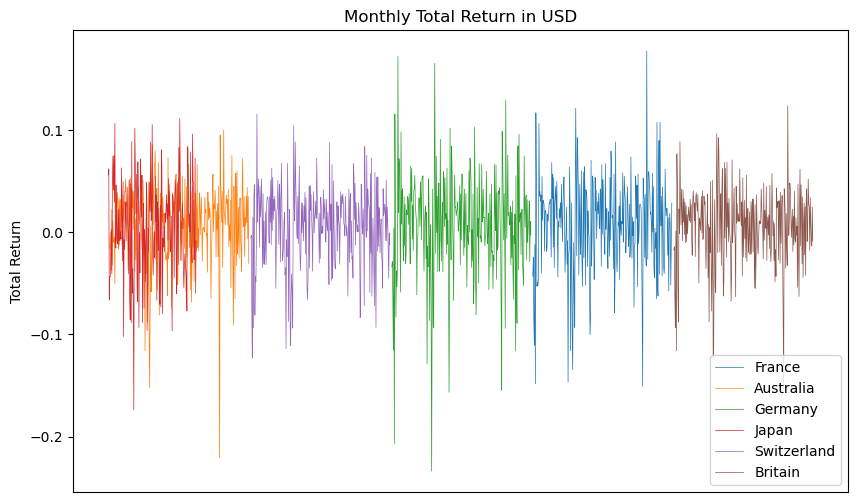

In [344]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(france['monthly_total_return_USD'], label='France', linestyle='-', linewidth=0.5)
plt.plot(australia['monthly_total_return_USD'], label='Australia', linestyle='-', linewidth=0.5)
plt.plot(germany['monthly_total_return_USD'], label='Germany', linestyle='-', linewidth=0.5)
plt.plot(japan['monthly_total_return_USD'], label='Japan', linestyle='-', linewidth=0.5)
plt.plot(switzerland['monthly_total_return_USD'], label='Switzerland', linestyle='-', linewidth=0.5)
plt.plot(britain['monthly_total_return_USD'], label='Britain', linestyle='-', linewidth=0.5)
plt.legend()
plt.title('Monthly Total Return in USD')
plt.ylabel('Total Return')
plt.xticks([])
plt.show()


### B. 